Epoch 500/500: 100%|██████████| 23/23 [00:00<00:00, 489.38it/s]

CNN weights saved to cnn_model_weights.pth


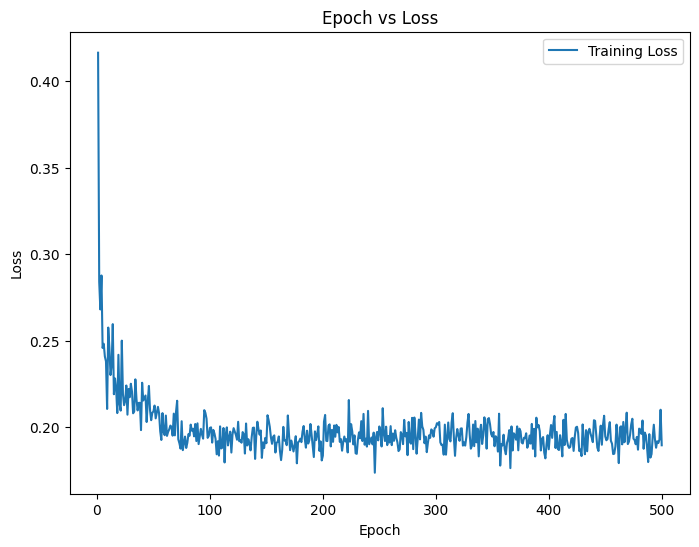

Best XGB parameters found: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Bagging + XGB model saved to Bagging_XGB_CNN_features.pkl
Bagging + XGBoost performance on validation set: MAE = 0.1793
Bagging + XGBoost performance on test set: MAE = 0.2214
Saved predictions and actual values to MCCX_plot.csv (rows=81)


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.ensemble import BaggingRegressor  # added import for Bagging
import random
import matplotlib.pyplot as plt  # for plotting
import joblib  # for saving XGB + Bagging model

# set random seed for reproducibility
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# 1. data preparation
# ------------------------------
def load_CSN_data():
    csv_path = '../../Master_List_LCPLCP.csv'
    return pd.read_csv(csv_path)

CSN = load_CSN_data()
CSN = CSN.drop(['Example ID', 'Source', 'Figure ID', 'Data Provider', 'PI',
                'Date Received', 'Data Measurment Published', 'Prior Exposure', 'Comments', 'Error'], axis=1)

CSN_prepared = pd.get_dummies(CSN, dtype=int)
CSN_prepared['Surface Area per Liter'] = CSN_prepared['Surface Area (NMC) (m2/g)'] * CSN_prepared['Concentration (mg/L)']
CSN_prepared = CSN_prepared.drop(['Surface Area (NMC) (m2/g)'], axis=1)
CSN_prepared['log Concentration'] = np.log10(CSN_prepared['Concentration (mg/L)'] + 1e-9)
CSN_prepared = CSN_prepared.drop(['Concentration (mg/L)'], axis=1)

X = CSN_prepared.drop(['Viability Fraction '], axis=1)
y = CSN_prepared['Viability Fraction ']

# split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

# define custom dataset class
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TabularDataset(X_train, y_train)
test_dataset = TabularDataset(X_test, y_test)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ------------------------------
# 2. define a 1D CNN model
# ------------------------------
class CNN(nn.Module):
    def __init__(self, num_features, feature_dim=128, dropout_prob=0.5):
        super(CNN, self).__init__()
        # Feature extractor part
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Flatten()
        )
        conv_out_size = num_features // 4  
        # Classifier part
        self.classifier = nn.Sequential(
            nn.Linear(32 * conv_out_size, feature_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(feature_dim, 1)
        )
    
    def forward(self, x, feature_extract=False):
        x = x.unsqueeze(1)
        features = self.feature_extractor(x)
        if feature_extract:
            features = self.classifier[0:2](features)  
            return features
        out = self.classifier(features)
        return out

num_features = X_train.shape[1]
model = CNN(num_features=num_features, feature_dim=128).to(device)

# ------------------------------
# 3. train the CNN model
# ------------------------------
criterion = nn.MSELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

num_epochs = 500
epoch_losses = []

model.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for data, target in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        data, target = data.to(device), target.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_losses.append(epoch_loss)
    scheduler.step(epoch_loss)

# Save CNN model weights
torch.save(model.state_dict(), "cnn_model_weights.pth")
print("CNN weights saved to cnn_model_weights.pth")

model.eval()

# Plot Epoch-Loss curve
plt.figure(figsize=(8, 6))
plt.plot(range(1, num_epochs+1), epoch_losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Epoch vs Loss")
plt.legend()
plt.show()

# ------------------------------
# 4. extract features from the CNN model
# ------------------------------
def extract_features(loader):
    features_list = []
    targets_list = []
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            feats = model(data, feature_extract=True)  # extract features
            features_list.append(feats.cpu().numpy())
            targets_list.append(target.cpu().numpy())
    features = np.concatenate(features_list, axis=0)
    targets = np.concatenate(targets_list, axis=0).flatten()
    return features, targets

train_features, train_targets = extract_features(train_loader)
test_features, test_targets = extract_features(test_loader)

# ------------------------------
# Split training features into XGB training and validation sets
# ------------------------------
X_xgb_train, X_val, y_xgb_train, y_val = train_test_split(train_features, train_targets, test_size=0.2, random_state=seed)

# ------------------------------
# 5. hyperparameter tuning for XGBoost using the XGB training subset
# ------------------------------
param_grid = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [7],
}

num_iterations = 10
best_params = None
best_score = float('inf')

for params in ParameterGrid(param_grid):
    scores = []
    weights = []
    for _ in range(num_iterations):
        test_size_cv = random.uniform(0.1, 0.3)
        X_train_mccv, X_val_cv, y_train_mccv, y_val_cv = train_test_split(
            X_xgb_train, y_xgb_train, test_size=test_size_cv, random_state=np.random.randint(0, 10000)
        )
        model_cv = XGBRegressor(objective='reg:squarederror', **params)
        model_cv.fit(X_train_mccv, y_train_mccv)
        
        y_val_pred = model_cv.predict(X_val_cv)
        score = mean_absolute_error(y_val_cv, y_val_pred)
        scores.append(score)
        weights.append(len(y_val_cv))
    
    weighted_avg_score = np.average(scores, weights=weights)
    if weighted_avg_score < best_score:
        best_score = weighted_avg_score
        best_params = params

print("Best XGB parameters found:", best_params)

# ------------------------------
# 6. use Bagging + XGBoost to predict test set
# ------------------------------
base_xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=seed,
    **best_params
)

bagging_reg = BaggingRegressor(
    estimator=base_xgb,
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=seed
)

bagging_reg.fit(X_xgb_train, y_xgb_train)

# Save the Bagging + XGB model
joblib.dump(bagging_reg, "Bagging_XGB_CNN_features.pkl")
print("Bagging + XGB model saved to Bagging_XGB_CNN_features.pkl")

# Predict on validation and test sets
y_pred_val_bag = bagging_reg.predict(X_val)
y_pred_test_bag = bagging_reg.predict(test_features)

val_mae_bag = mean_absolute_error(y_val, y_pred_val_bag)
test_mae_bag = mean_absolute_error(test_targets, y_pred_test_bag)

print(f"Bagging + XGBoost performance on validation set: MAE = {val_mae_bag:.4f}")
print(f"Bagging + XGBoost performance on test set: MAE = {test_mae_bag:.4f}")

# ------------------------------
# Save results to CSV for plotting
# ------------------------------

# create separate DataFrames for validation and test results
df_val = pd.DataFrame({
    "dataset": ["validation"] * len(y_val),
    "actual": y_val,
    "predicted": y_pred_val_bag
})

df_test = pd.DataFrame({
    "dataset": ["test"] * len(test_targets),
    "actual": test_targets,
    "predicted": y_pred_test_bag
})

# concatenate them into a single file
plot_df = pd.concat([df_val, df_test], ignore_index=True)
plot_df.to_csv("MCCX_plot.csv", index=False)
print(f"Saved predictions and actual values to MCCX_plot.csv (rows={len(plot_df)})")


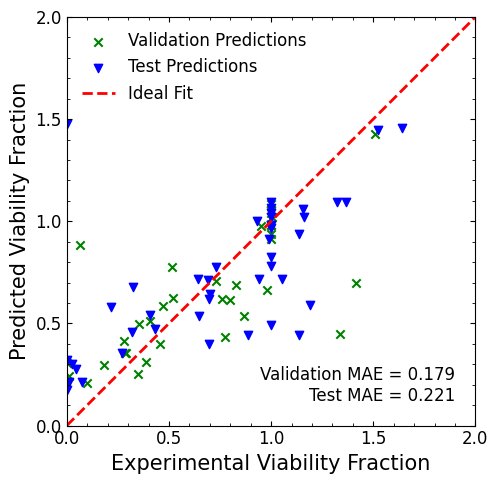

In [2]:
import matplotlib.pyplot as plt
import xgboost as xgb
import pandas as pd
import numpy as np

# ------------------------------
# 7. Plot Prediction vs Actual scatter plot (from saved CSV)
# ------------------------------
df_plot = pd.read_csv("MCCX_plot.csv")

#### Font Sizing
SMALL_SIZE = 12
MEDIUM_SIZE = 15
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
#### 

fig = plt.figure(figsize=(6.5, 5))
plt.rcParams["mathtext.fontset"] = "cm"
plt.minorticks_on()
plt.tick_params(axis='both', bottom=True, top=True, left=True, right=True, direction='in', which='both')

plt.scatter(
    df_plot[df_plot["dataset"] == "validation"]["actual"],
    df_plot[df_plot["dataset"] == "validation"]["predicted"],
    c='green', marker='x', label="Validation Predictions"
)
plt.scatter(
    df_plot[df_plot["dataset"] == "test"]["actual"],
    df_plot[df_plot["dataset"] == "test"]["predicted"],
    c='blue', marker='v', label="Test Predictions"
)

min_val = df_plot["actual"].min()
max_val = df_plot["actual"].max()
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--', label="Ideal Fit")

# Add MAE information to the bottom right
# transform=plt.gca().transAxes uses coordinates from 0 to 1 relative to the plot box
mae_text = (f"Validation MAE = 0.179\n"
            f"Test MAE = 0.221")
plt.gca().text(0.95, 0.05, mae_text, transform=plt.gca().transAxes,
               fontsize=SMALL_SIZE, verticalalignment='bottom', horizontalalignment='right')

plt.xlabel("Experimental Viability Fraction")
plt.ylabel("Predicted Viability Fraction")
plt.ylim(0, 2)
plt.yticks(np.arange(0, 2.1, 0.5))
plt.xlim(0, 2)
plt.xticks(np.arange(0, 2.1, 0.5))
plt.legend(framealpha=0.0, loc='upper left', ncol=1)

fig.tight_layout()
plt.gca().set_aspect('equal')
#plt.title("Predicted vs Actual Values (Bagging + XGB)")
#plt.show()
plt.savefig("MCCX_plot.pdf", dpi=300)